In [1]:
import torch
import flwr as fl
import opacus
import pandas as pd
import numpy as np
import sklearn

print("torch:", torch.__version__)
print("flwr:", fl.__version__)
print("opacus:", opacus.__version__)

torch: 2.14.0+cpu
flwr: 1.36.0
opacus: 1.6.0


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("RT_IOT2022.csv")

In [3]:
# 1. Shape & dtypes
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes.value_counts())
print("\nColumns:\n", list(df.columns))

Shape: (123117, 85)

Dtypes:
 float64    56
int64      26
str         3
Name: count, dtype: int64

Columns:
 ['no', 'id.orig_p', 'id.resp_p', 'proto', 'service', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot', 'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot', 'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count', 'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg', 'bwd_pkts_payload.std', 'flow_pkts_payload.min', 'flow_pkts_payload.max', 'flow_pkts_payl

In [4]:

# 2. Label distribution (find the target column — usually 'Attack_type' in RT-IoT2022)
label_col = "Attack_type"  # adjust if the actual column name differs
print("\nLabel distribution:\n", df[label_col].value_counts())


Label distribution:
 Attack_type
DOS_SYN_Hping                 94659
Thing_Speak                    8108
ARP_poisioning                 7750
MQTT_Publish                   4146
NMAP_UDP_SCAN                  2590
NMAP_XMAS_TREE_SCAN            2010
NMAP_OS_DETECTION              2000
NMAP_TCP_scan                  1002
DDOS_Slowloris                  534
Wipro_bulb                      253
Metasploit_Brute_Force_SSH       37
NMAP_FIN_SCAN                    28
Name: count, dtype: int64


In [5]:

# 3. Missing / infinite / duplicate checks
print("\nMissing values (top 10):\n", df.isnull().sum().sort_values(ascending=False).head(10))
num_df = df.select_dtypes(include=[np.number])
print("\nInfinite values:", np.isinf(num_df).sum().sum())
print("Duplicate rows:", df.duplicated().sum())



Missing values (top 10):
 no                   0
id.orig_p            0
id.resp_p            0
proto                0
service              0
flow_duration        0
fwd_pkts_tot         0
bwd_pkts_tot         0
fwd_data_pkts_tot    0
bwd_data_pkts_tot    0
dtype: int64

Infinite values: 0
Duplicate rows: 0


In [6]:

# 4. Candidate device-type / leakage columns — just eyeball these
print("\nSample rows:\n", df.head(3).T)


Sample rows:
                                  0             1             2
no                               0             1             2
id.orig_p                    38667         51143         44761
id.resp_p                     1883          1883          1883
proto                          tcp           tcp           tcp
service                       mqtt          mqtt          mqtt
...                            ...           ...           ...
idle.std                       0.0           0.0           0.0
fwd_init_window_size         64240         64240         64240
bwd_init_window_size         26847         26847         26847
fwd_last_window_size           502           502           502
Attack_type           MQTT_Publish  MQTT_Publish  MQTT_Publish

[85 rows x 3 columns]


In [7]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# 1. Drop the row-index column (no predictive value, pure leakage risk)
df = df.drop(columns=["no"])

In [8]:

# 2. Merge tiny classes into a single Rare_Attack bucket
rare_classes = ["Metasploit_Brute_Force_SSH", "NMAP_FIN_SCAN"]
df["Attack_type"] = df["Attack_type"].replace(rare_classes, "Rare_Attack")
print(df["Attack_type"].value_counts())


Attack_type
DOS_SYN_Hping          94659
Thing_Speak             8108
ARP_poisioning          7750
MQTT_Publish            4146
NMAP_UDP_SCAN           2590
NMAP_XMAS_TREE_SCAN     2010
NMAP_OS_DETECTION       2000
NMAP_TCP_scan           1002
DDOS_Slowloris           534
Wipro_bulb               253
Rare_Attack               65
Name: count, dtype: int64


In [9]:

# 3. Encode categorical features (proto, service — low cardinality, so LabelEncoder is fine here;
#    one-hot would explode dimensionality for little benefit given how few unique values these have)
cat_cols = ["proto", "service"]
for col in cat_cols:
    print(col, "unique values:", df[col].nunique())

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le


proto unique values: 3
service unique values: 10


In [10]:

# 4. Encode the target label separately (keep this encoder — you'll need it to map
#    predictions back to class names for confusion matrices / per-class reports)
target_encoder = LabelEncoder()
df["Attack_type_encoded"] = target_encoder.fit_transform(df["Attack_type"])
class_names = target_encoder.classes_
print("\nClasses:", list(class_names))



Classes: ['ARP_poisioning', 'DDOS_Slowloris', 'DOS_SYN_Hping', 'MQTT_Publish', 'NMAP_OS_DETECTION', 'NMAP_TCP_scan', 'NMAP_UDP_SCAN', 'NMAP_XMAS_TREE_SCAN', 'Rare_Attack', 'Thing_Speak', 'Wipro_bulb']


In [11]:

# 5. Stratified train/test split — BEFORE scaling, so the scaler only ever sees training data
X = df.drop(columns=["Attack_type", "Attack_type_encoded"])
y = df["Attack_type_encoded"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [12]:

# 6. Scale — fit ONLY on training data (Section 2.4: we're using the "fit once on full
#    pre-split training set" simplification, documented explicitly, rather than per-client
#    scalers — this is the methodological call to state plainly in your report)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nTrain shape:", X_train_scaled.shape, "Test shape:", X_test_scaled.shape)


Train shape: (98493, 83) Test shape: (24624, 83)


In [13]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
import time

device = torch.device("cpu")  # CPU is fine at this scale, per the guide


In [14]:
# 1. Wrap arrays in a PyTorch Dataset
class FlowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = FlowDataset(X_train_scaled, y_train)
test_ds = FlowDataset(X_test_scaled, y_test)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)


In [15]:
# 2. The MLP architecture exactly as specified in Section 3
class MLP(nn.Module):
    def __init__(self, n_features, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, n_classes)
        )
    def forward(self, x):
        return self.net(x)

n_features = X_train_scaled.shape[1]
n_classes = len(class_names)
model = MLP(n_features, n_classes).to(device)

In [16]:
# 3. Standard training loop
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    return total_loss / len(loader.dataset)

def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            preds = model(xb).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(yb.numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average="macro")
    f1_weighted = f1_score(all_labels, all_preds, average="weighted")
    prec_macro = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    rec_macro = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    return {
        "accuracy": acc, "f1_macro": f1_macro, "f1_weighted": f1_weighted,
        "precision_macro": prec_macro, "recall_macro": rec_macro,
        "preds": all_preds, "labels": all_labels
    }


In [17]:

# 4. Run training
NUM_EPOCHS = 20
start_time = time.time()
history = []
for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(model, train_loader)
    metrics = evaluate(model, test_loader)
    history.append({"epoch": epoch, "train_loss": train_loss, **{k: v for k, v in metrics.items() if k not in ("preds", "labels")}})
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | loss={train_loss:.4f} | acc={metrics['accuracy']:.4f} | f1_macro={metrics['f1_macro']:.4f}")

training_time = time.time() - start_time
print(f"\nTotal training time: {training_time:.1f}s")


Epoch 1/20 | loss=0.3553 | acc=0.9766 | f1_macro=0.7641
Epoch 2/20 | loss=0.0599 | acc=0.9823 | f1_macro=0.7968
Epoch 3/20 | loss=0.0427 | acc=0.9898 | f1_macro=0.8515
Epoch 4/20 | loss=0.0324 | acc=0.9926 | f1_macro=0.9059
Epoch 5/20 | loss=0.0267 | acc=0.9933 | f1_macro=0.8964
Epoch 6/20 | loss=0.0225 | acc=0.9940 | f1_macro=0.9200
Epoch 7/20 | loss=0.0197 | acc=0.9944 | f1_macro=0.9175
Epoch 8/20 | loss=0.0178 | acc=0.9943 | f1_macro=0.9178
Epoch 9/20 | loss=0.0176 | acc=0.9946 | f1_macro=0.9378
Epoch 10/20 | loss=0.0157 | acc=0.9945 | f1_macro=0.9539
Epoch 11/20 | loss=0.0152 | acc=0.9954 | f1_macro=0.9648
Epoch 12/20 | loss=0.0139 | acc=0.9955 | f1_macro=0.9673
Epoch 13/20 | loss=0.0137 | acc=0.9950 | f1_macro=0.9557
Epoch 14/20 | loss=0.0129 | acc=0.9956 | f1_macro=0.9611
Epoch 15/20 | loss=0.0123 | acc=0.9952 | f1_macro=0.9676
Epoch 16/20 | loss=0.0125 | acc=0.9957 | f1_macro=0.9597
Epoch 17/20 | loss=0.0121 | acc=0.9958 | f1_macro=0.9640
Epoch 18/20 | loss=0.0121 | acc=0.9953 |

In [18]:
# 5. Final detailed report
final_metrics = evaluate(model, test_loader)
print("\nConfusion Matrix:\n", confusion_matrix(final_metrics["labels"], final_metrics["preds"]))
print("\nClassification Report:\n", classification_report(final_metrics["labels"], final_metrics["preds"], target_names=class_names, zero_division=0))



Confusion Matrix:
 [[ 1526     1     0     0     0     1     0     0     0    22     0]
 [    1    86     0     0     0     0    20     0     0     0     0]
 [    0     0 18932     0     0     0     0     0     0     0     0]
 [    3     0     0   826     0     0     0     0     0     0     0]
 [    0     0     0     0   400     0     0     0     0     0     0]
 [    0     0     0     0     0   200     0     0     0     0     0]
 [    6     0     0     0     0     0   509     0     0     3     0]
 [    2     0     0     0     0     0     0   400     0     0     0]
 [    1     0     0     0     0     0     0     0    12     0     0]
 [   25     0     0     0     0     0     0     0     0  1596     1]
 [    0     0     0     0     3     0     0     0     0     5    43]]

Classification Report:
                      precision    recall  f1-score   support

     ARP_poisioning       0.98      0.98      0.98      1550
     DDOS_Slowloris       0.99      0.80      0.89       107
      DOS_S

In [19]:
centralized_baseline = final_metrics

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("figures", exist_ok=True)
sns.set_style("whitegrid")

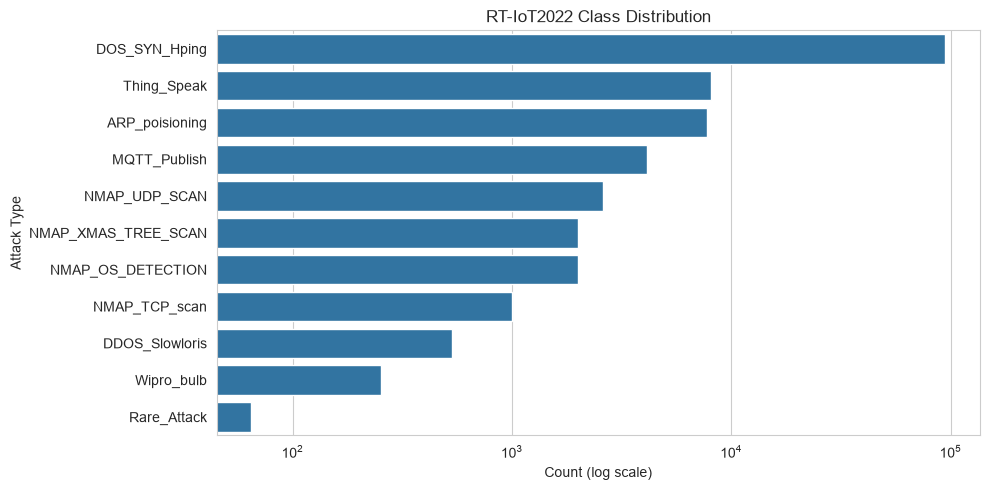

In [21]:
plt.figure(figsize=(10, 5))
counts = df["Attack_type"].value_counts()
sns.barplot(x=counts.values, y=counts.index, orient="h")
plt.xscale("log")
plt.xlabel("Count (log scale)")
plt.ylabel("Attack Type")
plt.title("RT-IoT2022 Class Distribution")
plt.tight_layout()
plt.savefig("figures/01_label_distribution.png", dpi=150)
plt.show()

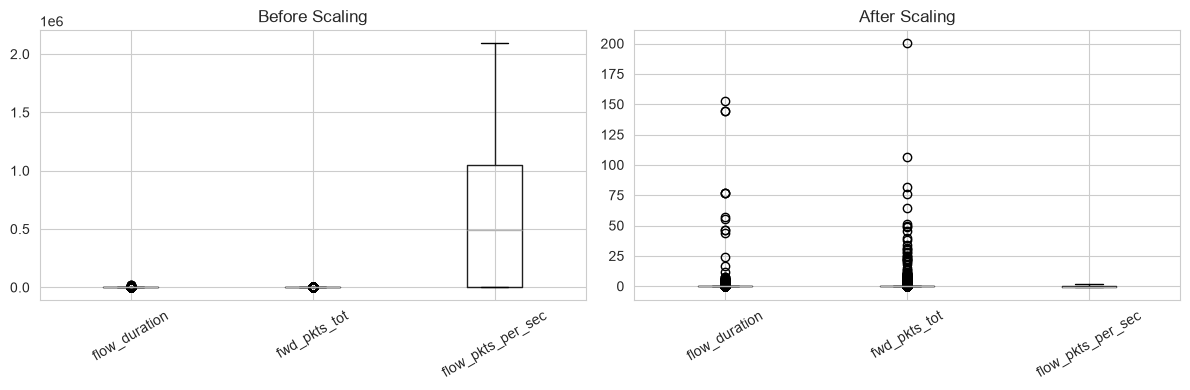

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sample_cols = ["flow_duration", "fwd_pkts_tot", "flow_pkts_per_sec"]
X_train[sample_cols].boxplot(ax=axes[0])
axes[0].set_title("Before Scaling")
axes[0].tick_params(axis='x', rotation=30)
pd.DataFrame(X_train_scaled, columns=X_train.columns)[sample_cols].boxplot(ax=axes[1])
axes[1].set_title("After Scaling")
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig("figures/02_scaling_effect.png", dpi=150)
plt.show()

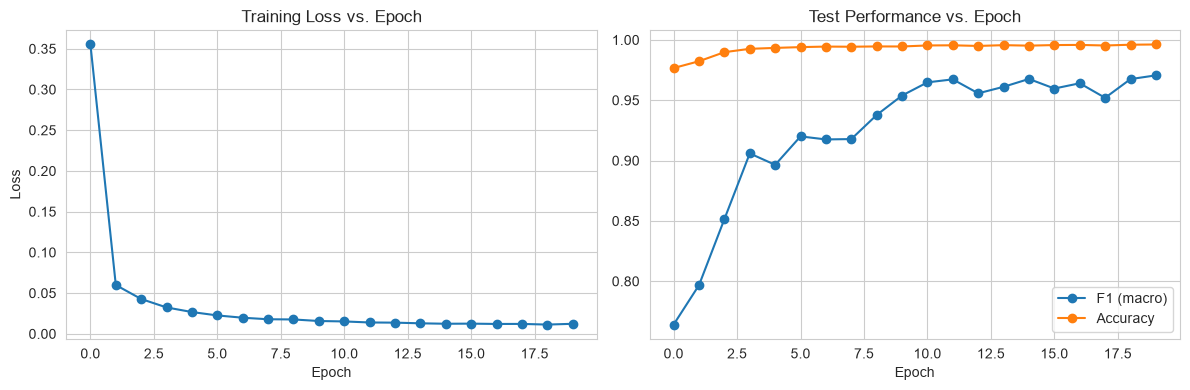

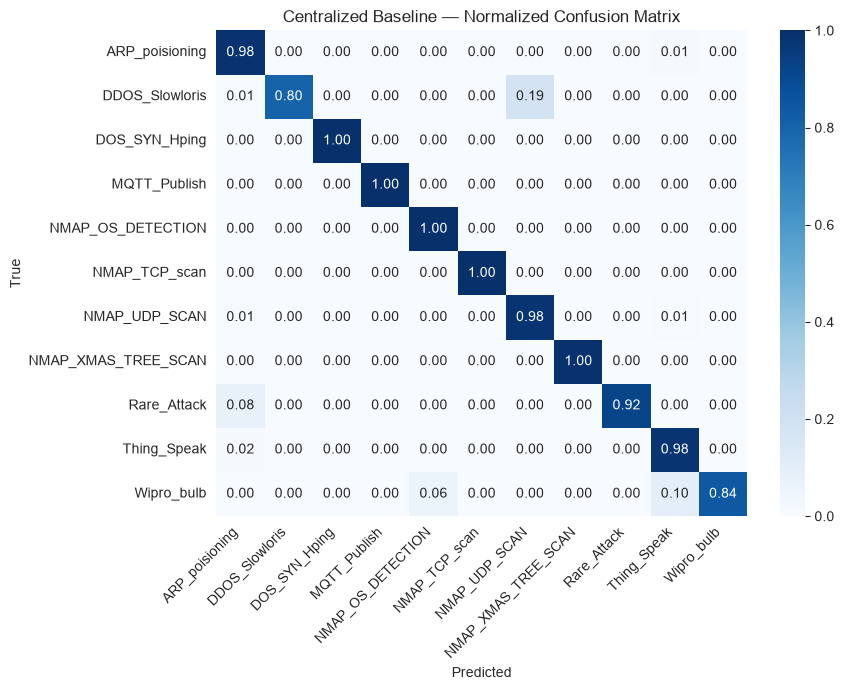

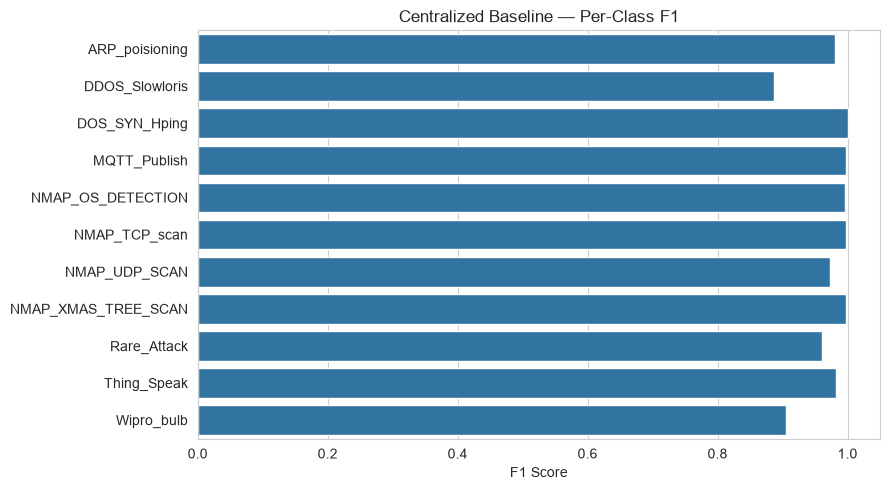

In [23]:
history_df = pd.DataFrame(history)

# Plot 3: Training curves (loss + F1 over epochs)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o")
axes[0].set_title("Training Loss vs. Epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")

axes[1].plot(history_df["epoch"], history_df["f1_macro"], marker="o", label="F1 (macro)")
axes[1].plot(history_df["epoch"], history_df["accuracy"], marker="o", label="Accuracy")
axes[1].set_title("Test Performance vs. Epoch")
axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.savefig("figures/03_centralized_training_curve.png", dpi=150)
plt.show()

# Plot 4: Confusion matrix (normalized, since class sizes vary hugely)
cm = confusion_matrix(final_metrics["labels"], final_metrics["preds"], normalize="true")
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Centralized Baseline — Normalized Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/04_centralized_confusion_matrix.png", dpi=150)
plt.show()

# Plot 5: Per-class F1 bar chart (this is the "which classes suffer most" figure, Section 7 plot 5 — centralized half)
from sklearn.metrics import f1_score as f1s
per_class_f1 = f1s(final_metrics["labels"], final_metrics["preds"], average=None, zero_division=0)
plt.figure(figsize=(9, 5))
sns.barplot(x=per_class_f1, y=class_names, orient="h")
plt.xlabel("F1 Score"); plt.title("Centralized Baseline — Per-Class F1")
plt.tight_layout()
plt.savefig("figures/05_centralized_per_class_f1.png", dpi=150)
plt.show()

In [24]:
best_epoch_row = history_df.loc[history_df["f1_macro"].idxmax()]
print("Best epoch:", best_epoch_row)

Best epoch: epoch              19.000000
train_loss          0.012256
accuracy            0.996183
f1_macro            0.970589
f1_weighted         0.996136
precision_macro     0.988437
recall_macro        0.955679
Name: 19, dtype: float64


In [25]:
import numpy as np

def dirichlet_partition(labels, num_clients, alpha, seed=42):
    rng = np.random.default_rng(seed)
    num_classes = len(np.unique(labels))
    client_indices = [[] for _ in range(num_clients)]
    for c in range(num_classes):
        idx_c = np.where(labels == c)[0]
        rng.shuffle(idx_c)
        proportions = rng.dirichlet(alpha=[alpha] * num_clients)
        splits = (np.cumsum(proportions) * len(idx_c)).astype(int)[:-1]
        for client_id, idx_split in enumerate(np.split(idx_c, splits)):
            client_indices[client_id].extend(idx_split.tolist())
    return client_indices

def iid_partition(labels, num_clients, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(labels))
    rng.shuffle(idx)
    return [arr.tolist() for arr in np.array_split(idx, num_clients)]

# Build the partitions we'll actually use in the experimental matrix (Section 6)
NUM_CLIENTS = 10  # core comparison uses 10 clients

partitions = {
    "iid": iid_partition(y_train, NUM_CLIENTS),
    "dirichlet_a100": dirichlet_partition(y_train, NUM_CLIENTS, alpha=100),
    "dirichlet_a1": dirichlet_partition(y_train, NUM_CLIENTS, alpha=1.0),
    "dirichlet_a0.1": dirichlet_partition(y_train, NUM_CLIENTS, alpha=0.1),
}

for name, part in partitions.items():
    sizes = [len(p) for p in part]
    print(f"{name}: client sizes = {sizes}")

iid: client sizes = [9850, 9850, 9850, 9849, 9849, 9849, 9849, 9849, 9849, 9849]
dirichlet_a100: client sizes = [9737, 9870, 10105, 9238, 10539, 9662, 11227, 10527, 7995, 9593]
dirichlet_a1: client sizes = [8161, 2855, 13148, 7087, 4058, 14338, 2686, 21332, 14174, 10654]
dirichlet_a0.1: client sizes = [2261, 680, 4070, 3552, 51930, 704, 888, 20357, 7521, 6530]


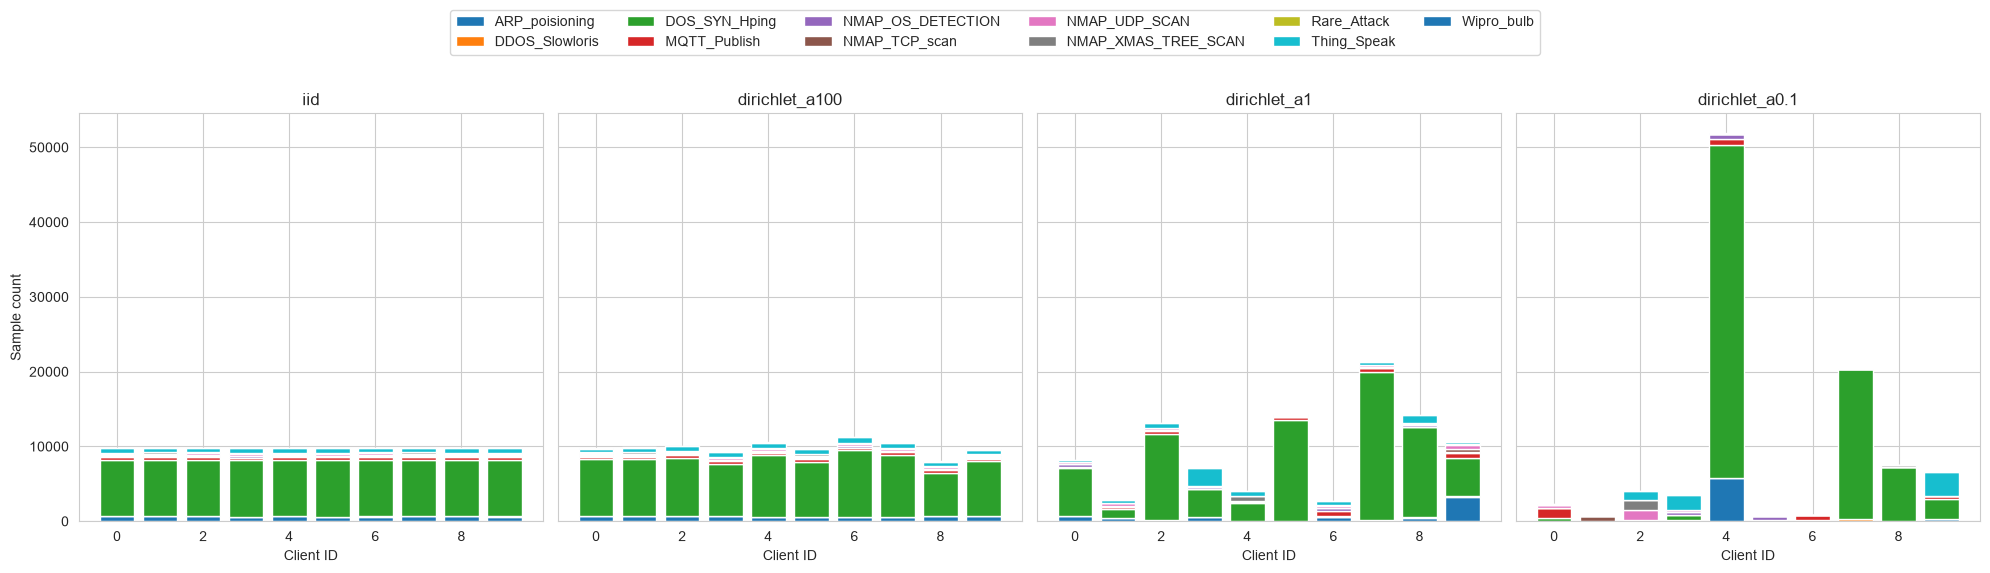

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
for ax, (name, part) in zip(axes, partitions.items()):
    class_counts = np.zeros((NUM_CLIENTS, n_classes))
    for client_id, idxs in enumerate(part):
        labels_here = y_train[idxs]
        for c in range(n_classes):
            class_counts[client_id, c] = np.sum(labels_here == c)
    # stacked bar: each client's class composition
    bottom = np.zeros(NUM_CLIENTS)
    for c in range(n_classes):
        ax.bar(range(NUM_CLIENTS), class_counts[:, c], bottom=bottom, label=class_names[c])
        bottom += class_counts[:, c]
    ax.set_title(name)
    ax.set_xlabel("Client ID")
axes[0].set_ylabel("Sample count")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=6, bbox_to_anchor=(0.5, 1.15))
plt.tight_layout()
plt.savefig("figures/06_partition_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

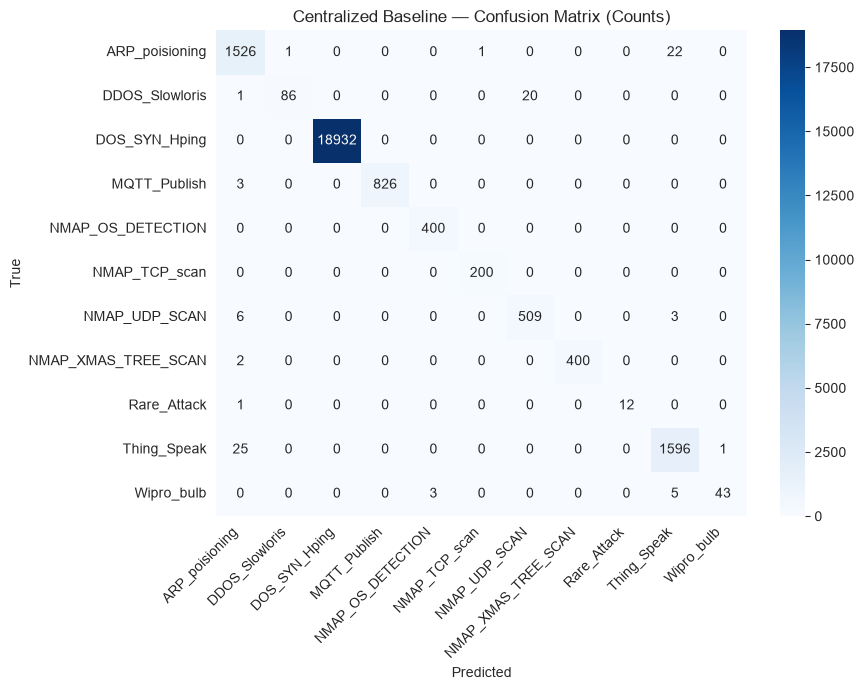

In [27]:
cm_counts = confusion_matrix(final_metrics["labels"], final_metrics["preds"])

plt.figure(figsize=(9, 7))
sns.heatmap(cm_counts, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Centralized Baseline — Confusion Matrix (Counts)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/04b_centralized_confusion_matrix_counts.png", dpi=150)
plt.show()

In [28]:
import flwr
print(flwr.__version__)

1.36.0


In [30]:
def average_weights(state_dicts, client_sizes):
    """Weighted average of state_dicts, weighted by each client's local dataset size — same weighting FedAvg uses."""
    total = sum(client_sizes)
    avg_state = copy.deepcopy(state_dicts[0])
    for key in avg_state.keys():
        avg_state[key] = torch.zeros_like(avg_state[key], dtype=torch.float32)
        for state_dict, size in zip(state_dicts, client_sizes):
            avg_state[key] += state_dict[key].float() * (size / total)
    return avg_state

def run_fedavg_manual(partition, num_clients, num_rounds=30, local_epochs=1, label="run"):
    global_model = MLP(n_features, n_classes).to(device)
    test_loader = DataLoader(FlowDataset(X_test_scaled, y_test), batch_size=256, shuffle=False)
    history = []
    start = time.time()

    for rnd in range(1, num_rounds + 1):
        local_states, client_sizes = [], []
        for client_id in range(num_clients):
            idxs = partition[client_id]
            local_model = copy.deepcopy(global_model)
            local_optimizer = torch.optim.Adam(local_model.parameters(), lr=1e-3)
            local_loader = DataLoader(FlowDataset(X_train_scaled[idxs], y_train[idxs]), batch_size=64, shuffle=True)

            local_model.train()
            for _ in range(local_epochs):
                for xb, yb in local_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    local_optimizer.zero_grad()
                    loss = criterion(local_model(xb), yb)
                    loss.backward()
                    local_optimizer.step()

            local_states.append(local_model.state_dict())
            client_sizes.append(len(idxs))

        # Aggregate: weighted average of all client weights
        global_model.load_state_dict(average_weights(local_states, client_sizes))

        # Evaluate global model on held-out test set
        metrics = evaluate(global_model, test_loader)
        history.append({"round": rnd, "accuracy": metrics["accuracy"],
                         "f1_macro": metrics["f1_macro"], "f1_weighted": metrics["f1_weighted"]})
        print(f"[{label}] Round {rnd}/{num_rounds}: acc={metrics['accuracy']:.4f} f1_macro={metrics['f1_macro']:.4f}")

    elapsed = time.time() - start
    print(f"{label} finished in {elapsed:.1f}s")
    return pd.DataFrame(history), elapsed, global_model

# Run the core comparison case: 10 clients, IID
fedavg_iid_history, fedavg_iid_time, fedavg_iid_model = run_fedavg_manual(
    partitions["iid"], num_clients=NUM_CLIENTS, num_rounds=30, local_epochs=1, label="FedAvg-IID"
)

[FedAvg-IID] Round 1/30: acc=0.9256 f1_macro=0.5393
[FedAvg-IID] Round 2/30: acc=0.9709 f1_macro=0.7260
[FedAvg-IID] Round 3/30: acc=0.9764 f1_macro=0.7723
[FedAvg-IID] Round 4/30: acc=0.9768 f1_macro=0.7886
[FedAvg-IID] Round 5/30: acc=0.9782 f1_macro=0.8000
[FedAvg-IID] Round 6/30: acc=0.9807 f1_macro=0.8297
[FedAvg-IID] Round 7/30: acc=0.9816 f1_macro=0.8331
[FedAvg-IID] Round 8/30: acc=0.9821 f1_macro=0.8331
[FedAvg-IID] Round 9/30: acc=0.9825 f1_macro=0.8366
[FedAvg-IID] Round 10/30: acc=0.9869 f1_macro=0.8425
[FedAvg-IID] Round 11/30: acc=0.9888 f1_macro=0.8460
[FedAvg-IID] Round 12/30: acc=0.9894 f1_macro=0.8489
[FedAvg-IID] Round 13/30: acc=0.9905 f1_macro=0.8494
[FedAvg-IID] Round 14/30: acc=0.9918 f1_macro=0.8507
[FedAvg-IID] Round 15/30: acc=0.9921 f1_macro=0.8512
[FedAvg-IID] Round 16/30: acc=0.9925 f1_macro=0.8513
[FedAvg-IID] Round 17/30: acc=0.9928 f1_macro=0.8520
[FedAvg-IID] Round 18/30: acc=0.9930 f1_macro=0.8541
[FedAvg-IID] Round 19/30: acc=0.9931 f1_macro=0.8533
[F

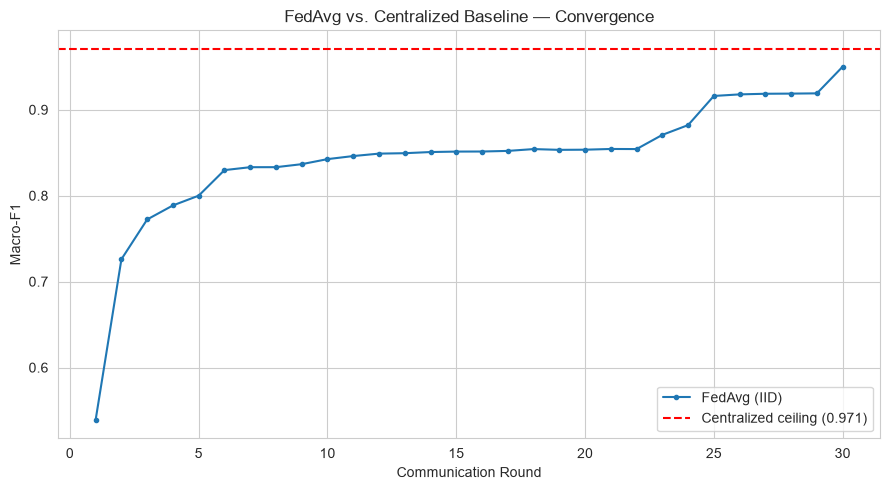

In [31]:
plt.figure(figsize=(9, 5))
plt.plot(fedavg_iid_history["round"], fedavg_iid_history["f1_macro"], marker="o", label="FedAvg (IID)", markersize=3)
plt.axhline(y=best_epoch_row["f1_macro"], color="red", linestyle="--", label=f"Centralized ceiling ({best_epoch_row['f1_macro']:.3f})")
plt.xlabel("Communication Round")
plt.ylabel("Macro-F1")
plt.title("FedAvg vs. Centralized Baseline — Convergence")
plt.legend()
plt.tight_layout()
plt.savefig("figures/07_fedavg_iid_vs_centralized.png", dpi=150)
plt.show()

In [32]:
# Non-IID severity sweep (10 clients, using the 3 remaining partitions)
fedavg_a100_history, fedavg_a100_time, _ = run_fedavg_manual(
    partitions["dirichlet_a100"], num_clients=NUM_CLIENTS, num_rounds=30, local_epochs=1, label="FedAvg-a100"
)
fedavg_a1_history, fedavg_a1_time, _ = run_fedavg_manual(
    partitions["dirichlet_a1"], num_clients=NUM_CLIENTS, num_rounds=30, local_epochs=1, label="FedAvg-a1"
)
fedavg_a01_history, fedavg_a01_time, _ = run_fedavg_manual(
    partitions["dirichlet_a0.1"], num_clients=NUM_CLIENTS, num_rounds=30, local_epochs=1, label="FedAvg-a0.1"
)

# Client-count sweep (IID, 5 and 20 clients — need fresh partitions at those sizes)
partitions_5 = {"iid": iid_partition(y_train, 5)}
partitions_20 = {"iid": iid_partition(y_train, 20)}

fedavg_5c_history, fedavg_5c_time, _ = run_fedavg_manual(
    partitions_5["iid"], num_clients=5, num_rounds=30, local_epochs=1, label="FedAvg-5clients"
)
fedavg_20c_history, fedavg_20c_time, _ = run_fedavg_manual(
    partitions_20["iid"], num_clients=20, num_rounds=30, local_epochs=1, label="FedAvg-20clients"
)

[FedAvg-a100] Round 1/30: acc=0.9384 f1_macro=0.5258
[FedAvg-a100] Round 2/30: acc=0.9716 f1_macro=0.7417
[FedAvg-a100] Round 3/30: acc=0.9761 f1_macro=0.7829
[FedAvg-a100] Round 4/30: acc=0.9787 f1_macro=0.8184
[FedAvg-a100] Round 5/30: acc=0.9792 f1_macro=0.8272
[FedAvg-a100] Round 6/30: acc=0.9806 f1_macro=0.8278
[FedAvg-a100] Round 7/30: acc=0.9809 f1_macro=0.8323
[FedAvg-a100] Round 8/30: acc=0.9821 f1_macro=0.8363
[FedAvg-a100] Round 9/30: acc=0.9838 f1_macro=0.8404
[FedAvg-a100] Round 10/30: acc=0.9847 f1_macro=0.8425
[FedAvg-a100] Round 11/30: acc=0.9893 f1_macro=0.8504
[FedAvg-a100] Round 12/30: acc=0.9892 f1_macro=0.8508
[FedAvg-a100] Round 13/30: acc=0.9911 f1_macro=0.8622
[FedAvg-a100] Round 14/30: acc=0.9910 f1_macro=0.9058
[FedAvg-a100] Round 15/30: acc=0.9913 f1_macro=0.9063
[FedAvg-a100] Round 16/30: acc=0.9926 f1_macro=0.9055
[FedAvg-a100] Round 17/30: acc=0.9928 f1_macro=0.9061
[FedAvg-a100] Round 18/30: acc=0.9920 f1_macro=0.9078
[FedAvg-a100] Round 19/30: acc=0.9936

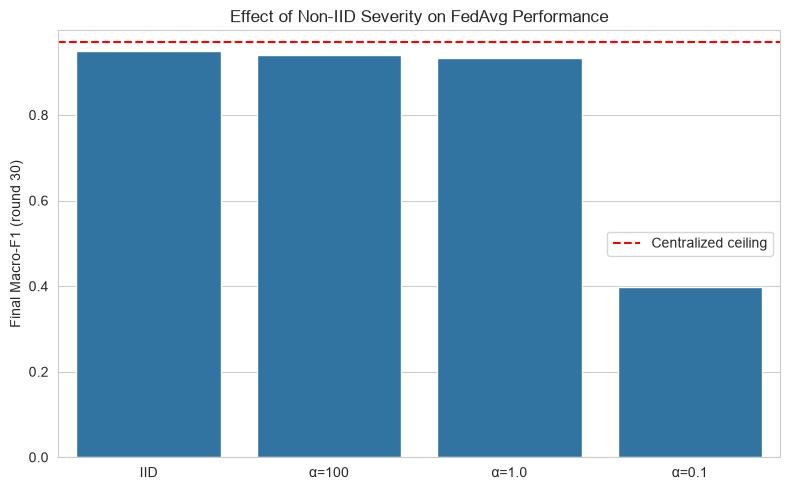

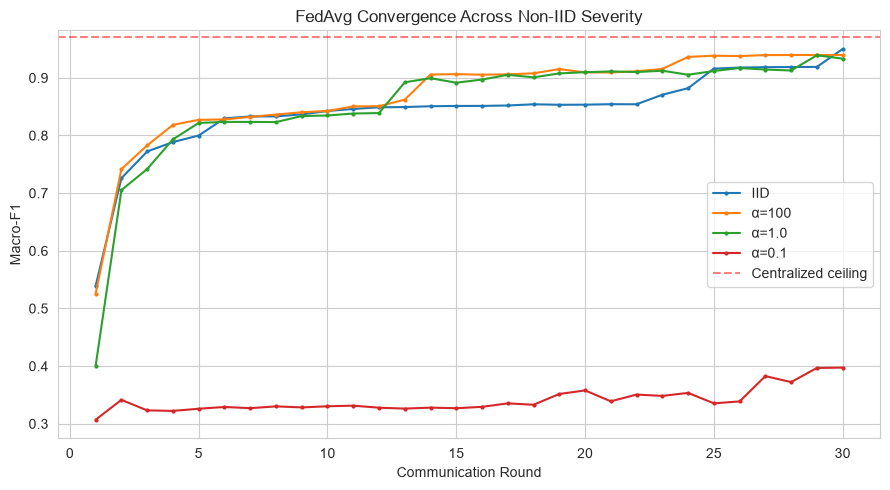

In [33]:
severity_results = {
    "IID": fedavg_iid_history["f1_macro"].iloc[-1],
    "α=100": fedavg_a100_history["f1_macro"].iloc[-1],
    "α=1.0": fedavg_a1_history["f1_macro"].iloc[-1],
    "α=0.1": fedavg_a01_history["f1_macro"].iloc[-1],
}
plt.figure(figsize=(8, 5))
sns.barplot(x=list(severity_results.keys()), y=list(severity_results.values()))
plt.axhline(y=best_epoch_row["f1_macro"], color="red", linestyle="--", label="Centralized ceiling")
plt.ylabel("Final Macro-F1 (round 30)")
plt.title("Effect of Non-IID Severity on FedAvg Performance")
plt.legend()
plt.tight_layout()
plt.savefig("figures/08_noniid_severity_sweep.png", dpi=150)
plt.show()

# Also plot full convergence curves for all 4, overlaid — shows WHERE they diverge, not just endpoint
plt.figure(figsize=(9, 5))
for name, hist in [("IID", fedavg_iid_history), ("α=100", fedavg_a100_history),
                     ("α=1.0", fedavg_a1_history), ("α=0.1", fedavg_a01_history)]:
    plt.plot(hist["round"], hist["f1_macro"], marker="o", markersize=2, label=name)
plt.axhline(y=best_epoch_row["f1_macro"], color="red", linestyle="--", alpha=0.5, label="Centralized ceiling")
plt.xlabel("Communication Round"); plt.ylabel("Macro-F1")
plt.title("FedAvg Convergence Across Non-IID Severity")
plt.legend()
plt.tight_layout()
plt.savefig("figures/09_noniid_convergence_curves.png", dpi=150)
plt.show() 

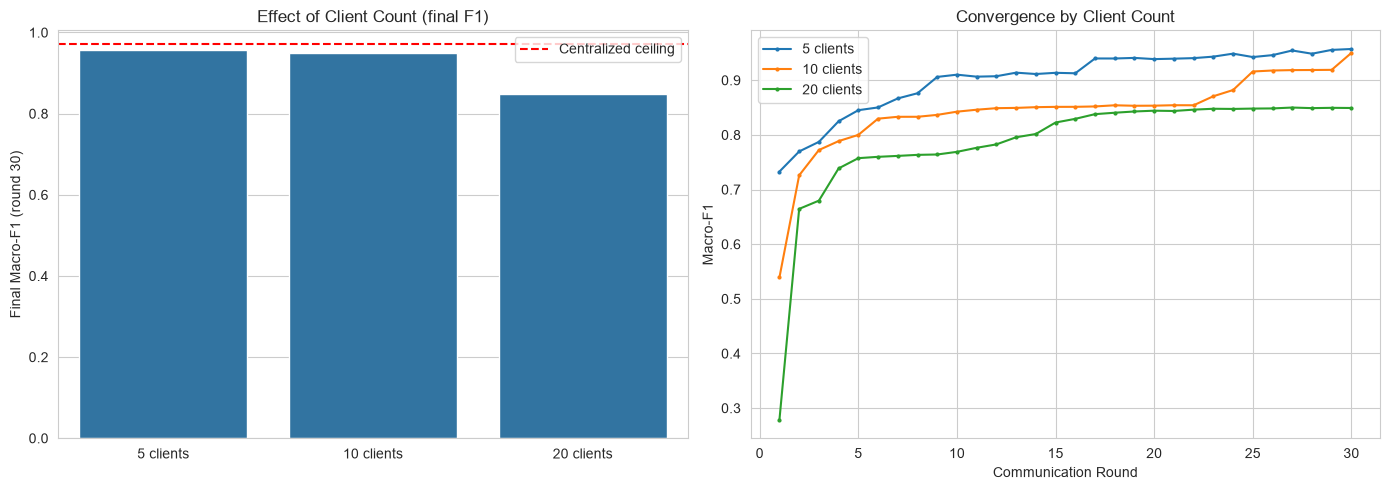

In [34]:
clientcount_results = {
    "5 clients": fedavg_5c_history["f1_macro"].iloc[-1],
    "10 clients": fedavg_iid_history["f1_macro"].iloc[-1],
    "20 clients": fedavg_20c_history["f1_macro"].iloc[-1],
}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=list(clientcount_results.keys()), y=list(clientcount_results.values()), ax=axes[0])
axes[0].axhline(y=best_epoch_row["f1_macro"], color="red", linestyle="--", label="Centralized ceiling")
axes[0].set_ylabel("Final Macro-F1 (round 30)")
axes[0].set_title("Effect of Client Count (final F1)")
axes[0].legend()

for name, hist in [("5 clients", fedavg_5c_history), ("10 clients", fedavg_iid_history), ("20 clients", fedavg_20c_history)]:
    axes[1].plot(hist["round"], hist["f1_macro"], marker="o", markersize=2, label=name)
axes[1].set_xlabel("Communication Round"); axes[1].set_ylabel("Macro-F1")
axes[1].set_title("Convergence by Client Count")
axes[1].legend()
plt.tight_layout()
plt.savefig("figures/10_clientcount_sweep.png", dpi=150)
plt.show()

In [36]:
from opacus import PrivacyEngine

def run_dp_fedavg_manual(partition, num_clients, num_rounds=30, local_epochs=1,
                           noise_multiplier=1.0, max_grad_norm=1.0, label="run"):
    global_model = MLP(n_features, n_classes).to(device)
    test_loader = DataLoader(FlowDataset(X_test_scaled, y_test), batch_size=256, shuffle=False)
    history = []
    start = time.time()

    for rnd in range(1, num_rounds + 1):
        local_states, client_sizes, round_epsilons = [], [], []

        for client_id in range(num_clients):
            idxs = partition[client_id]
            local_model = copy.deepcopy(global_model)
            local_model.train()  # <-- the fix
            local_optimizer = torch.optim.Adam(local_model.parameters(), lr=1e-3)
            local_loader = DataLoader(FlowDataset(X_train_scaled[idxs], y_train[idxs]), batch_size=64, shuffle=True)

            privacy_engine = PrivacyEngine()
            dp_model, dp_optimizer, dp_loader = privacy_engine.make_private(
                module=local_model,
                optimizer=local_optimizer,
                data_loader=local_loader,
                noise_multiplier=noise_multiplier,
                max_grad_norm=max_grad_norm,
            )

            dp_model.train()
            for _ in range(local_epochs):
                for xb, yb in dp_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    dp_optimizer.zero_grad()
                    loss = criterion(dp_model(xb), yb)
                    loss.backward()
                    dp_optimizer.step()

            eps = privacy_engine.get_epsilon(delta=1e-5)
            round_epsilons.append(eps)
            local_states.append(dp_model._module.state_dict())
            client_sizes.append(len(idxs))

        global_model.load_state_dict(average_weights(local_states, client_sizes))
        metrics = evaluate(global_model, test_loader)
        max_eps = max(round_epsilons)
        history.append({
            "round": rnd, "accuracy": metrics["accuracy"], "f1_macro": metrics["f1_macro"],
            "f1_weighted": metrics["f1_weighted"], "epsilon": max_eps
        })
        print(f"[{label}] Round {rnd}/{num_rounds}: acc={metrics['accuracy']:.4f} f1_macro={metrics['f1_macro']:.4f} eps={max_eps:.2f}")

    elapsed = time.time() - start
    print(f"{label} finished in {elapsed:.1f}s")
    return pd.DataFrame(history), elapsed, global_model

# Run the privacy-utility sweep: 10 clients, IID, 3 noise levels (Section 6, 4th bullet)
dp_05_history, dp_05_time, _ = run_dp_fedavg_manual(
    partitions["iid"], num_clients=NUM_CLIENTS, num_rounds=30, noise_multiplier=0.5, label="DP-noise0.5"
)
dp_10_history, dp_10_time, _ = run_dp_fedavg_manual(
    partitions["iid"], num_clients=NUM_CLIENTS, num_rounds=30, noise_multiplier=1.0, label="DP-noise1.0"
)
dp_15_history, dp_15_time, _ = run_dp_fedavg_manual(
    partitions["iid"], num_clients=NUM_CLIENTS, num_rounds=30, noise_multiplier=1.5, label="DP-noise1.5"
)

C:\Users\adila\AppData\Local\Temp\ipykernel_22312\2536866737.py:35: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


[DP-noise0.5] Round 1/30: acc=0.8715 f1_macro=0.2549 eps=5.70


C:\Users\adila\OneDrive\Desktop\Research Stuff\cicids\Lib\site-packages\opacus\privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
C:\Users\adila\AppData\Local\Temp\ipykernel_22312\2536866737.py:35: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


[DP-noise0.5] Round 2/30: acc=0.8847 f1_macro=0.2665 eps=5.70


C:\Users\adila\OneDrive\Desktop\Research Stuff\cicids\Lib\site-packages\opacus\privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
C:\Users\adila\AppData\Local\Temp\ipykernel_22312\2536866737.py:35: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


...

[DP-noise1.5] Round 28/30: acc=0.9432 f1_macro=0.6319 eps=0.23


C:\Users\adila\OneDrive\Desktop\Research Stuff\cicids\Lib\site-packages\opacus\privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
C:\Users\adila\AppData\Local\Temp\ipykernel_22312\2536866737.py:35: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


[DP-noise1.5] Round 29/30: acc=0.9470 f1_macro=0.6379 eps=0.23


C:\Users\adila\OneDrive\Desktop\Research Stuff\cicids\Lib\site-packages\opacus\privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
C:\Users\adila\AppData\Local\Temp\ipykernel_22312\2536866737.py:35: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


[DP-noise1.5] Round 30/30: acc=0.9506 f1_macro=0.6438 eps=0.23
DP-noise1.5 finished in 372.1s


   noise_multiplier   epsilon  final_f1_macro
0               0.5  5.701808        0.727498
1               1.0  0.539565        0.672823
2               1.5  0.233326        0.643805


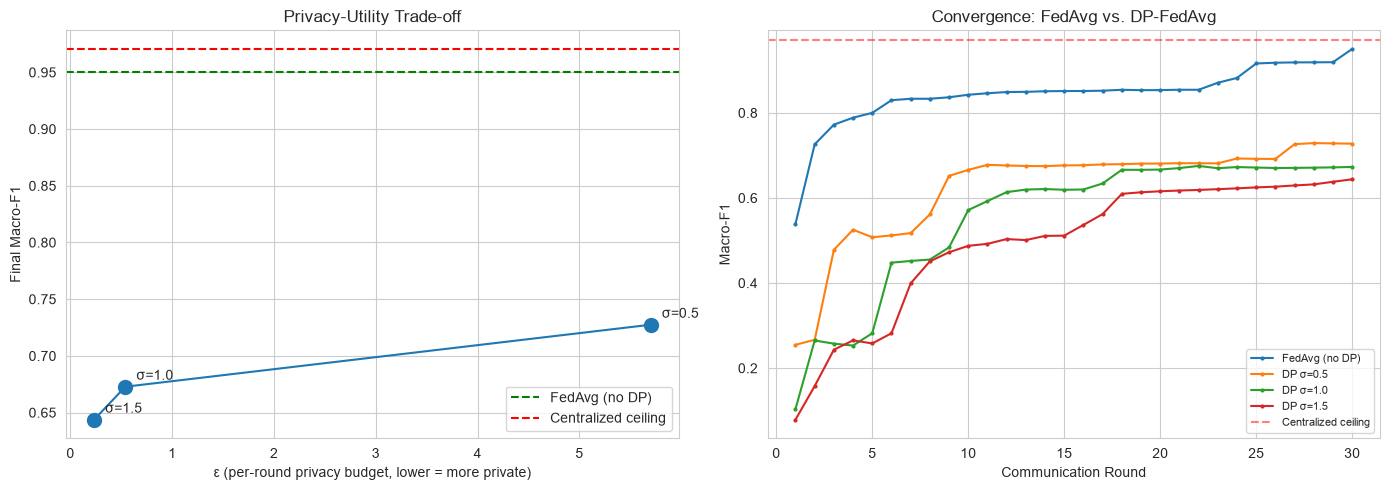

In [37]:
privacy_utility = pd.DataFrame({
    "noise_multiplier": [0.5, 1.0, 1.5],
    "epsilon": [dp_05_history["epsilon"].iloc[0], dp_10_history["epsilon"].iloc[0], dp_15_history["epsilon"].iloc[0]],
    "final_f1_macro": [dp_05_history["f1_macro"].iloc[-1], dp_10_history["f1_macro"].iloc[-1], dp_15_history["f1_macro"].iloc[-1]],
})
print(privacy_utility)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: F1 vs epsilon (the core trade-off curve)
axes[0].plot(privacy_utility["epsilon"], privacy_utility["final_f1_macro"], marker="o", markersize=10, linestyle="-")
for _, row in privacy_utility.iterrows():
    axes[0].annotate(f"σ={row['noise_multiplier']}", (row["epsilon"], row["final_f1_macro"]),
                      textcoords="offset points", xytext=(8, 5))
axes[0].axhline(y=fedavg_iid_history["f1_macro"].iloc[-1], color="green", linestyle="--", label="FedAvg (no DP)")
axes[0].axhline(y=best_epoch_row["f1_macro"], color="red", linestyle="--", label="Centralized ceiling")
axes[0].set_xlabel("ε (per-round privacy budget, lower = more private)")
axes[0].set_ylabel("Final Macro-F1")
axes[0].set_title("Privacy-Utility Trade-off")
axes[0].legend()

# Right: convergence curves for all 3 noise levels + plain FedAvg + centralized reference
axes[1].plot(fedavg_iid_history["round"], fedavg_iid_history["f1_macro"], label="FedAvg (no DP)", marker="o", markersize=2)
for name, hist in [("DP σ=0.5", dp_05_history), ("DP σ=1.0", dp_10_history), ("DP σ=1.5", dp_15_history)]:
    axes[1].plot(hist["round"], hist["f1_macro"], label=name, marker="o", markersize=2)
axes[1].axhline(y=best_epoch_row["f1_macro"], color="red", linestyle="--", alpha=0.5, label="Centralized ceiling")
axes[1].set_xlabel("Communication Round"); axes[1].set_ylabel("Macro-F1")
axes[1].set_title("Convergence: FedAvg vs. DP-FedAvg")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("figures/11_privacy_utility_tradeoff.png", dpi=150)
plt.show()

C:\Users\adila\OneDrive\Desktop\Research Stuff\cicids\Lib\site-packages\opacus\privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
C:\Users\adila\AppData\Local\Temp\ipykernel_22312\2536866737.py:35: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


[DP-final-for-plot] Round 1/30: acc=0.7688 f1_macro=0.0790 eps=0.54


C:\Users\adila\OneDrive\Desktop\Research Stuff\cicids\Lib\site-packages\opacus\privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
C:\Users\adila\AppData\Local\Temp\ipykernel_22312\2536866737.py:35: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


[DP-final-for-plot] Round 2/30: acc=0.8666 f1_macro=0.2415 eps=0.54


C:\Users\adila\OneDrive\Desktop\Research Stuff\cicids\Lib\site-packages\opacus\privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
C:\Users\adila\AppData\Local\Temp\ipykernel_22312\2536866737.py:35: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


...

[DP-final-for-plot] Round 28/30: acc=0.9691 f1_macro=0.6745 eps=0.54


C:\Users\adila\OneDrive\Desktop\Research Stuff\cicids\Lib\site-packages\opacus\privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
C:\Users\adila\AppData\Local\Temp\ipykernel_22312\2536866737.py:35: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


[DP-final-for-plot] Round 29/30: acc=0.9692 f1_macro=0.6748 eps=0.54


C:\Users\adila\OneDrive\Desktop\Research Stuff\cicids\Lib\site-packages\opacus\privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
C:\Users\adila\AppData\Local\Temp\ipykernel_22312\2536866737.py:35: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


[DP-final-for-plot] Round 30/30: acc=0.9693 f1_macro=0.6748 eps=0.54
DP-final-for-plot finished in 687.3s


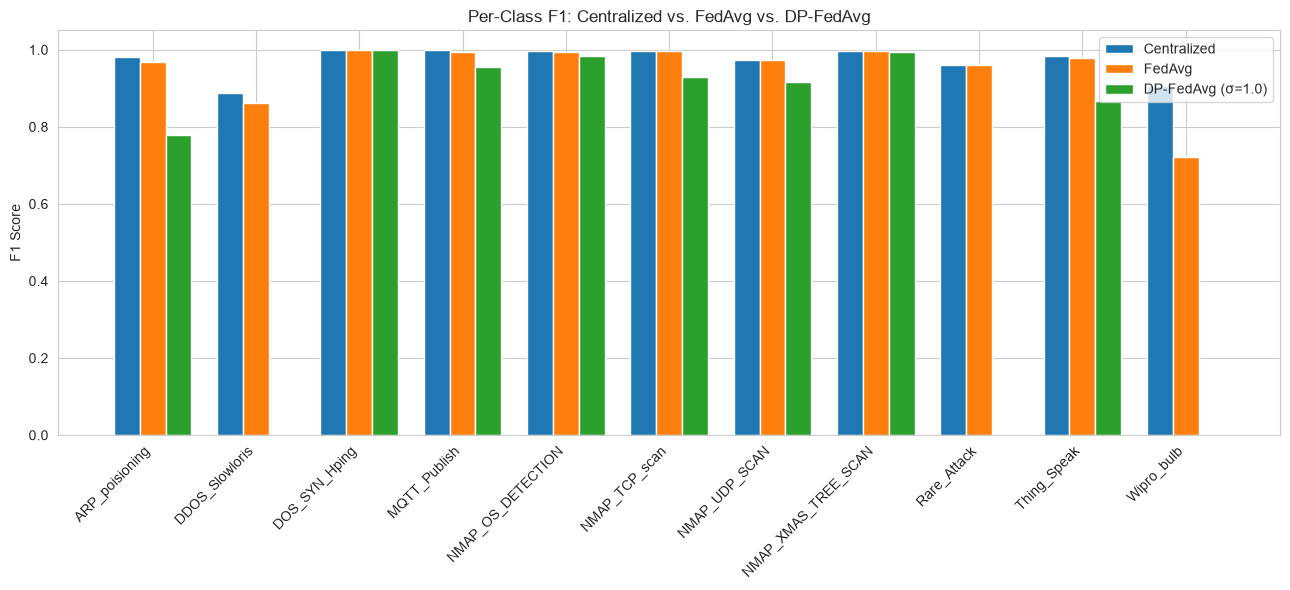

In [38]:
def get_final_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            preds = model(xb.to(device)).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(yb.numpy())
    return all_labels, all_preds

# Reuse the fedavg_iid_model and a DP model (use noise=1.0 as the representative DP case)
_, _, dp_10_model = run_dp_fedavg_manual(partitions["iid"], NUM_CLIENTS, num_rounds=30, noise_multiplier=1.0, label="DP-final-for-plot")

labels_c, preds_c = final_metrics["labels"], final_metrics["preds"]  # centralized, already have this
labels_f, preds_f = get_final_predictions(fedavg_iid_model, test_loader)
labels_d, preds_d = get_final_predictions(dp_10_model, test_loader)

f1_c = f1s(labels_c, preds_c, average=None, zero_division=0)
f1_f = f1s(labels_f, preds_f, average=None, zero_division=0)
f1_d = f1s(labels_d, preds_d, average=None, zero_division=0)

x = np.arange(len(class_names))
width = 0.25
plt.figure(figsize=(13, 6))
plt.bar(x - width, f1_c, width, label="Centralized")
plt.bar(x, f1_f, width, label="FedAvg")
plt.bar(x + width, f1_d, width, label="DP-FedAvg (σ=1.0)")
plt.xticks(x, class_names, rotation=45, ha="right")
plt.ylabel("F1 Score")
plt.title("Per-Class F1: Centralized vs. FedAvg vs. DP-FedAvg")
plt.legend()
plt.tight_layout()
plt.savefig("figures/12_per_class_f1_comparison.png", dpi=150)
plt.show()

                                   model_size_mb  total_params  \
FedAvg (10 clients, 30 rounds)          0.029827        7819.0   
FedAvg (5 clients, 30 rounds)           0.029827        7819.0   
FedAvg (20 clients, 30 rounds)          0.029827        7819.0   
DP-FedAvg (10 clients, 30 rounds)       0.029827        7819.0   

                                   transfers_per_round  total_communication_mb  
FedAvg (10 clients, 30 rounds)                    20.0               17.896271  
FedAvg (5 clients, 30 rounds)                     10.0                8.948135  
FedAvg (20 clients, 30 rounds)                    40.0               35.792542  
DP-FedAvg (10 clients, 30 rounds)                 20.0               17.896271  


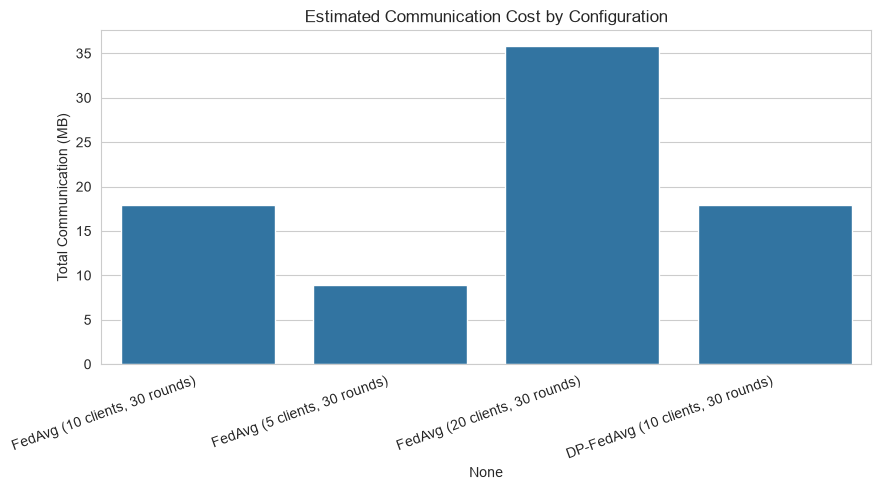

In [39]:
def estimate_communication_cost(model, num_clients, num_rounds, bidirectional=True):
    """
    Estimate total communication cost in MB.
    Each round: server sends global weights to each client (download),
    each client sends local weights back (upload).
    """
    total_params = sum(p.numel() for p in model.parameters())
    bytes_per_param = 4  # float32
    model_size_mb = (total_params * bytes_per_param) / (1024 ** 2)

    transfers_per_round = num_clients * (2 if bidirectional else 1)  # down + up per client
    total_mb = model_size_mb * transfers_per_round * num_rounds

    return {
        "model_size_mb": model_size_mb,
        "total_params": total_params,
        "transfers_per_round": transfers_per_round,
        "total_communication_mb": total_mb
    }

# Compute for your key experiments
comm_costs = {
    "FedAvg (10 clients, 30 rounds)": estimate_communication_cost(fedavg_iid_model, 10, 30),
    "FedAvg (5 clients, 30 rounds)": estimate_communication_cost(fedavg_iid_model, 5, 30),
    "FedAvg (20 clients, 30 rounds)": estimate_communication_cost(fedavg_iid_model, 20, 30),
    "DP-FedAvg (10 clients, 30 rounds)": estimate_communication_cost(dp_10_model, 10, 30),
}

comm_df = pd.DataFrame(comm_costs).T
print(comm_df)

plt.figure(figsize=(9, 5))
sns.barplot(x=comm_df.index, y=comm_df["total_communication_mb"])
plt.ylabel("Total Communication (MB)")
plt.title("Estimated Communication Cost by Configuration")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("figures/13_communication_cost.png", dpi=150)
plt.show()

In [40]:
from scipy.stats import wilcoxon

SEEDS = [42, 123, 7]  # 3 seeds is the minimum the guide allows; add more if time permits

def run_centralized_seeded(seed):
    torch.manual_seed(seed)
    model = MLP(n_features, n_classes).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    crit = nn.CrossEntropyLoss()
    loader = DataLoader(train_ds, batch_size=256, shuffle=True)
    for _ in range(15):  # use best_epoch's round count as a fair, fixed budget
        model.train()
        for xb, yb in loader:
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()
    return evaluate(model, test_loader)["f1_macro"]

def run_fedavg_seeded(seed):
    part = iid_partition(y_train, NUM_CLIENTS, seed=seed)
    hist, _, _ = run_fedavg_manual(part, NUM_CLIENTS, num_rounds=30, label=f"seed{seed}")
    return hist["f1_macro"].iloc[-1]

def run_dp_fedavg_seeded(seed):
    part = iid_partition(y_train, NUM_CLIENTS, seed=seed)
    hist, _, _ = run_dp_fedavg_manual(part, NUM_CLIENTS, num_rounds=30, noise_multiplier=1.0, label=f"DPseed{seed}")
    return hist["f1_macro"].iloc[-1]

results_centralized, results_fedavg, results_dp = [], [], []
for seed in SEEDS:
    print(f"--- Seed {seed} ---")
    results_centralized.append(run_centralized_seeded(seed))
    results_fedavg.append(run_fedavg_seeded(seed))
    results_dp.append(run_dp_fedavg_seeded(seed))

seed_results = pd.DataFrame({
    "seed": SEEDS, "centralized": results_centralized,
    "fedavg": results_fedavg, "dp_fedavg": results_dp
})
print(seed_results)
print("\nMean ± Std:")
print(seed_results[["centralized", "fedavg", "dp_fedavg"]].agg(["mean", "std"]))

# Wilcoxon signed-rank test: does FedAvg differ significantly from Centralized?
stat_fc, p_fc = wilcoxon(results_fedavg, results_centralized)
stat_fd, p_fd = wilcoxon(results_fedavg, results_dp)
print(f"\nWilcoxon FedAvg vs Centralized: stat={stat_fc:.3f}, p={p_fc:.4f}")
print(f"Wilcoxon FedAvg vs DP-FedAvg: stat={stat_fd:.3f}, p={p_fd:.4f}")

--- Seed 42 ---
[seed42] Round 1/30: acc=0.9648 f1_macro=0.6599
[seed42] Round 2/30: acc=0.9733 f1_macro=0.7298
[seed42] Round 3/30: acc=0.9767 f1_macro=0.7672
[seed42] Round 4/30: acc=0.9769 f1_macro=0.7754
[seed42] Round 5/30: acc=0.9786 f1_macro=0.7852
[seed42] Round 6/30: acc=0.9812 f1_macro=0.8300
[seed42] Round 7/30: acc=0.9821 f1_macro=0.8330
[seed42] Round 8/30: acc=0.9838 f1_macro=0.8382
[seed42] Round 9/30: acc=0.9869 f1_macro=0.8429
[seed42] Round 10/30: acc=0.9888 f1_macro=0.8476
[seed42] Round 11/30: acc=0.9893 f1_macro=0.8480
[seed42] Round 12/30: acc=0.9892 f1_macro=0.8479
[seed42] Round 13/30: acc=0.9895 f1_macro=0.8459
[seed42] Round 14/30: acc=0.9898 f1_macro=0.8463
[seed42] Round 15/30: acc=0.9909 f1_macro=0.8478
[seed42] Round 16/30: acc=0.9922 f1_macro=0.8497
[seed42] Round 17/30: acc=0.9929 f1_macro=0.8507
[seed42] Round 18/30: acc=0.9931 f1_macro=0.8509
[seed42] Round 19/30: acc=0.9931 f1_macro=0.8510
[seed42] Round 20/30: acc=0.9928 f1_macro=0.8519
[seed42] Roun

C:\Users\adila\OneDrive\Desktop\Research Stuff\cicids\Lib\site-packages\opacus\privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
C:\Users\adila\AppData\Local\Temp\ipykernel_22312\2536866737.py:35: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


[DPseed42] Round 1/30: acc=0.7689 f1_macro=0.0793 eps=0.54


C:\Users\adila\OneDrive\Desktop\Research Stuff\cicids\Lib\site-packages\opacus\privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
C:\Users\adila\AppData\Local\Temp\ipykernel_22312\2536866737.py:35: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


[DPseed42] Round 2/30: acc=0.8685 f1_macro=0.2576 eps=0.54


...

[DPseed7] Round 28/30: acc=0.9692 f1_macro=0.6757 eps=0.54


C:\Users\adila\OneDrive\Desktop\Research Stuff\cicids\Lib\site-packages\opacus\privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
C:\Users\adila\AppData\Local\Temp\ipykernel_22312\2536866737.py:35: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


[DPseed7] Round 29/30: acc=0.9721 f1_macro=0.6800 eps=0.54


C:\Users\adila\OneDrive\Desktop\Research Stuff\cicids\Lib\site-packages\opacus\privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
C:\Users\adila\AppData\Local\Temp\ipykernel_22312\2536866737.py:35: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


[DPseed7] Round 30/30: acc=0.9708 f1_macro=0.6776 eps=0.54
DPseed7 finished in 342.6s
   seed  centralized    fedavg  dp_fedavg
0    42     0.954808  0.949060   0.677192
1   123     0.961300  0.936562   0.677310
2     7     0.967807  0.915615   0.677638

Mean ± Std:
      centralized    fedavg  dp_fedavg
mean     0.961305  0.933746   0.677380
std      0.006500  0.016899   0.000231

Wilcoxon FedAvg vs Centralized: stat=0.000, p=0.2500
Wilcoxon FedAvg vs DP-FedAvg: stat=0.000, p=0.2500


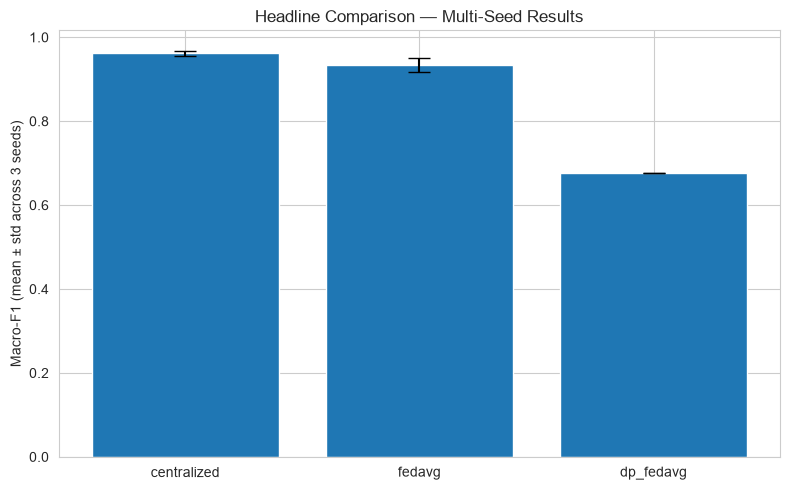

In [41]:
plt.figure(figsize=(8, 5))
means = seed_results[["centralized", "fedavg", "dp_fedavg"]].mean()
stds = seed_results[["centralized", "fedavg", "dp_fedavg"]].std()
plt.bar(means.index, means.values, yerr=stds.values, capsize=8)
plt.ylabel("Macro-F1 (mean ± std across 3 seeds)")
plt.title("Headline Comparison — Multi-Seed Results")
plt.tight_layout()
plt.savefig("figures/14_multiseed_headline_comparison.png", dpi=150)
plt.show()